# 1. Data Preparation

In [70]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np

In [71]:
X, y = fetch_openml('mnist_784', return_X_y = True,)
print(X.shape, y.shape)

(70000, 784) (70000,)


In [72]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [73]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [75]:
X_train,X_test,y_train,y_test = train_test_split(X , y , test_size=0.3, random_state=42, stratify=y)

# 2. Model Training

Logistic Regression 

In [76]:
model = LogisticRegression()

model.fit(X_train,y_train)


c:\Users\alsai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [77]:
y_predict = model.predict(X_test)

Support Vector Machine (SVM)

In [78]:
from sklearn.svm import SVC

In [79]:
svc = SVC()
svc.fit(X_train,y_train)

SVC_Y_PRED = svc.predict(X_test)

Decision Tree Classifier

In [80]:
from sklearn.tree import DecisionTreeClassifier


In [81]:
dtc = DecisionTreeClassifier(max_depth=10, random_state=42)
dtc.fit(X_train, y_train)
y_pred_tree = dtc.predict(X_test)

Random Forest Classifier

In [82]:
from sklearn.ensemble import RandomForestClassifier

In [83]:

rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

XGBoost Classifier

In [84]:
from xgboost import XGBClassifier


In [85]:
xgboost = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
X_trainXG = X_train.astype(int)
y_trainXG = y_train.astype(int)
y_testXG = y_test.astype(int)
xgboost.fit(X_trainXG, y_trainXG)
y_pred_xgb = xgboost.predict(X_test)

c:\Users\alsai\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:58:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# 3. Model Evaluation

Logistic Regression

In [86]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_test, y_predict)
recall = recall_score(y_test, y_predict, average = 'micro')
f1 = f1_score(y_test, y_predict, average = 'micro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(classification_report(y_test, y_predict))

Accuracy: 0.92
Recall: 0.9177
F1-Score: 0.9177
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      2071
           1       0.96      0.97      0.97      2363
           2       0.91      0.89      0.90      2097
           3       0.89      0.89      0.89      2142
           4       0.92      0.91      0.92      2047
           5       0.90      0.86      0.88      1894
           6       0.94      0.95      0.94      2063
           7       0.93      0.93      0.93      2188
           8       0.88      0.89      0.88      2048
           9       0.89      0.89      0.89      2087

    accuracy                           0.92     21000
   macro avg       0.92      0.92      0.92     21000
weighted avg       0.92      0.92      0.92     21000



Support Vector Machine (SVM)

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_test, SVC_Y_PRED)
precision = precision_score(y_test, SVC_Y_PRED, average = 'micro')
recall = recall_score(y_test, SVC_Y_PRED, average = 'micro')
f1 = f1_score(y_test, SVC_Y_PRED, average = 'micro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(classification_report(y_test, SVC_Y_PRED))

Accuracy: 0.98
Precision: 0.9768
Recall: 0.9768
F1-Score: 0.9768
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2071
           1       0.98      0.99      0.99      2363
           2       0.98      0.98      0.98      2097
           3       0.98      0.97      0.97      2142
           4       0.98      0.97      0.97      2047
           5       0.98      0.97      0.98      1894
           6       0.98      0.99      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.97      0.97      0.97      2048
           9       0.96      0.96      0.96      2087

    accuracy                           0.98     21000
   macro avg       0.98      0.98      0.98     21000
weighted avg       0.98      0.98      0.98     21000



Decision Tree Classifier

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_test, SVC_Y_PRED)
precision = precision_score(y_test, SVC_Y_PRED, average = 'micro')
recall = recall_score(y_test, SVC_Y_PRED, average = 'micro')
f1 = f1_score(y_test, y_pred_tree, average = 'micro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.98
Precision: 0.9768
Recall: 0.9768
F1-Score: 0.8512
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2071
           1       0.91      0.95      0.93      2363
           2       0.85      0.82      0.83      2097
           3       0.83      0.79      0.81      2142
           4       0.86      0.84      0.85      2047
           5       0.81      0.77      0.79      1894
           6       0.88      0.90      0.89      2063
           7       0.85      0.89      0.87      2188
           8       0.79      0.78      0.79      2048
           9       0.80      0.83      0.81      2087

    accuracy                           0.85     21000
   macro avg       0.85      0.85      0.85     21000
weighted avg       0.85      0.85      0.85     21000



Random Forest Classifier

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average = 'micro')
recall = recall_score(y_test, y_pred_rf, average = 'micro')
f1 = f1_score(y_test, y_pred_rf, average = 'micro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.97
Precision: 0.9665
Recall: 0.9665
F1-Score: 0.9665
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2071
           1       0.98      0.99      0.98      2363
           2       0.96      0.97      0.97      2097
           3       0.96      0.96      0.96      2142
           4       0.97      0.96      0.96      2047
           5       0.97      0.96      0.97      1894
           6       0.97      0.98      0.98      2063
           7       0.97      0.96      0.97      2188
           8       0.95      0.95      0.95      2048
           9       0.94      0.94      0.94      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000



XGBoost Classifier

In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_testXG, y_pred_xgb)
precision = precision_score(y_testXG, y_pred_xgb, average = 'weighted')
recall = recall_score(y_testXG, y_pred_xgb, average = 'weighted')                        
f1 = f1_score(y_testXG, y_pred_xgb, average = 'weighted')        
print(f"Accuracy: {accuracy:.2f}")      
print(f"Precision: {precision:.4f}")    
print(f"Recall: {recall:.4f}")  
print(f"F1-Score: {f1:.4f}")    
print(classification_report(y_testXG, y_pred_xgb))

Accuracy: 0.97
Precision: 0.9749
Recall: 0.9749
F1-Score: 0.9749
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2071
           1       0.99      0.99      0.99      2363
           2       0.98      0.98      0.98      2097
           3       0.98      0.97      0.98      2142
           4       0.98      0.96      0.97      2047
           5       0.98      0.97      0.97      1894
           6       0.97      0.98      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.97      0.97      0.97      2048
           9       0.96      0.96      0.96      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000



# 4. Error Analysis

In [91]:
import random
import matplotlib.pyplot as plt

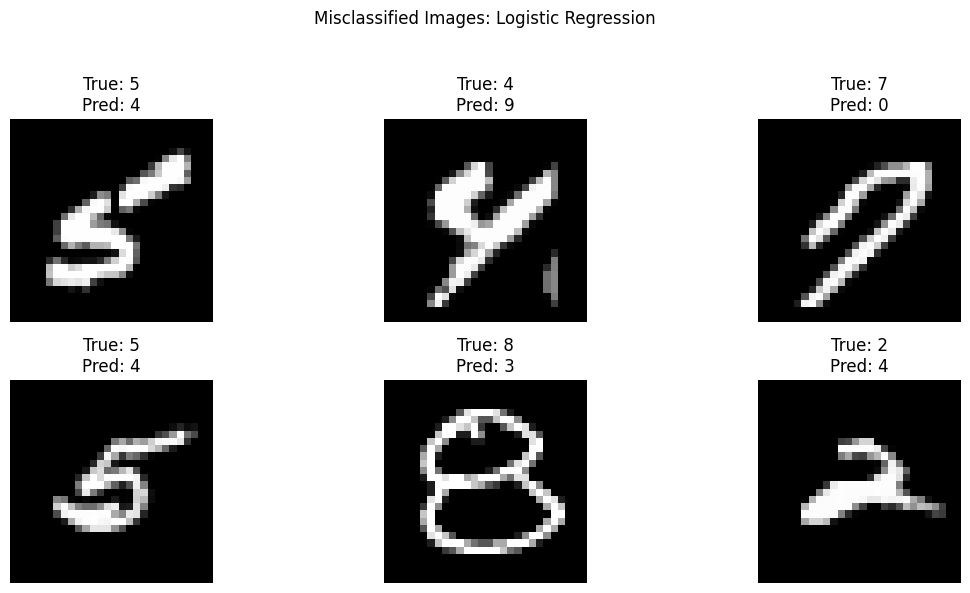

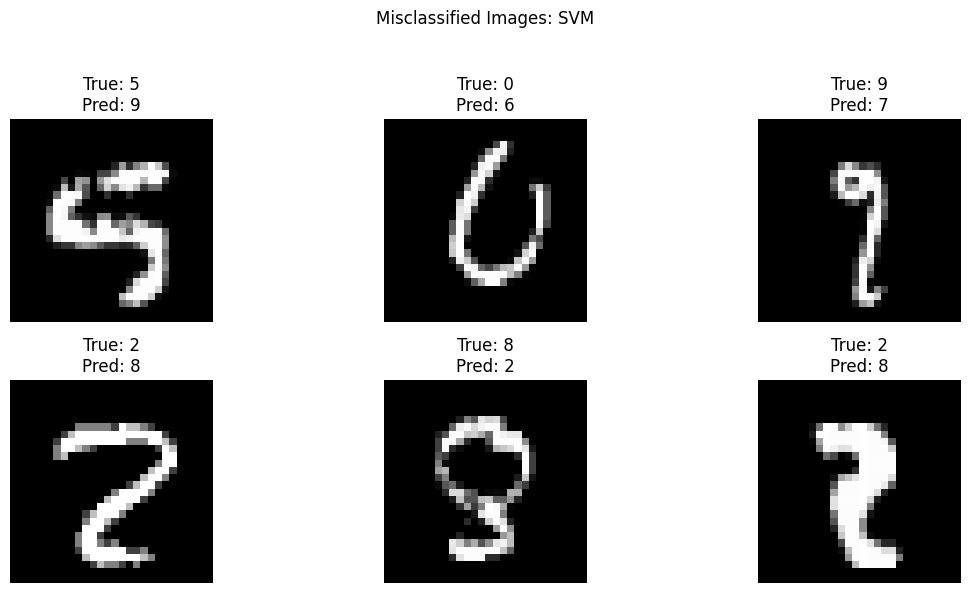

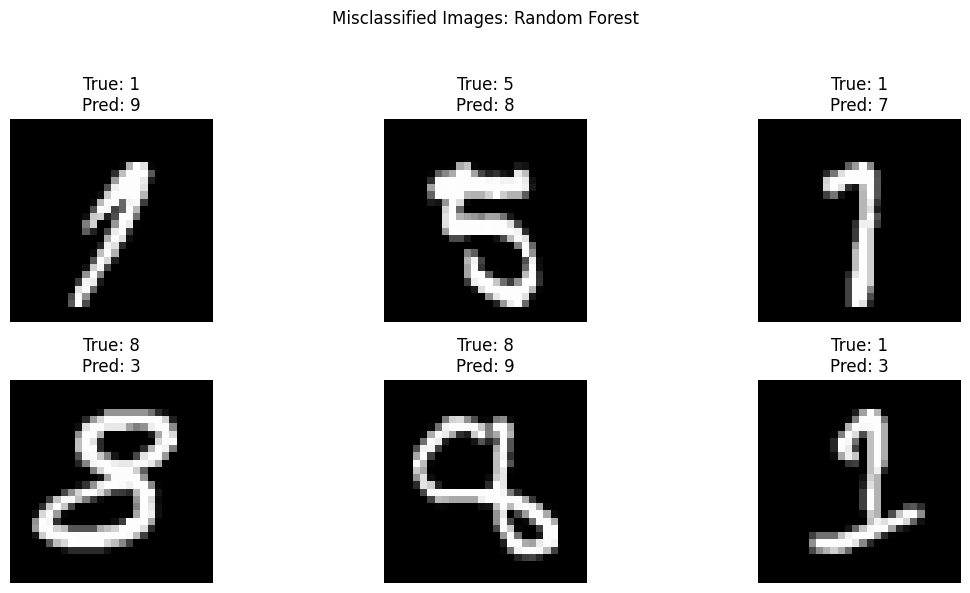

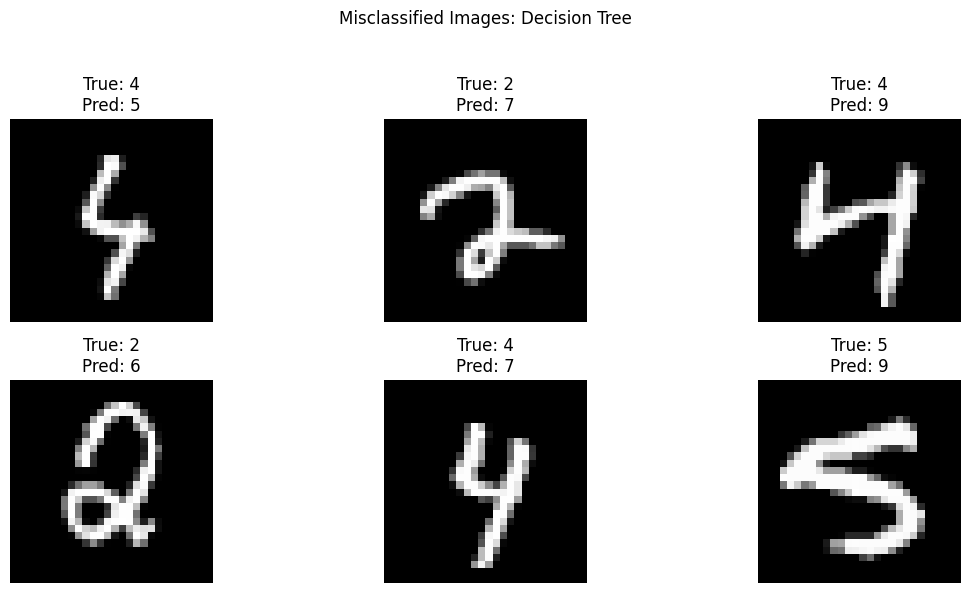

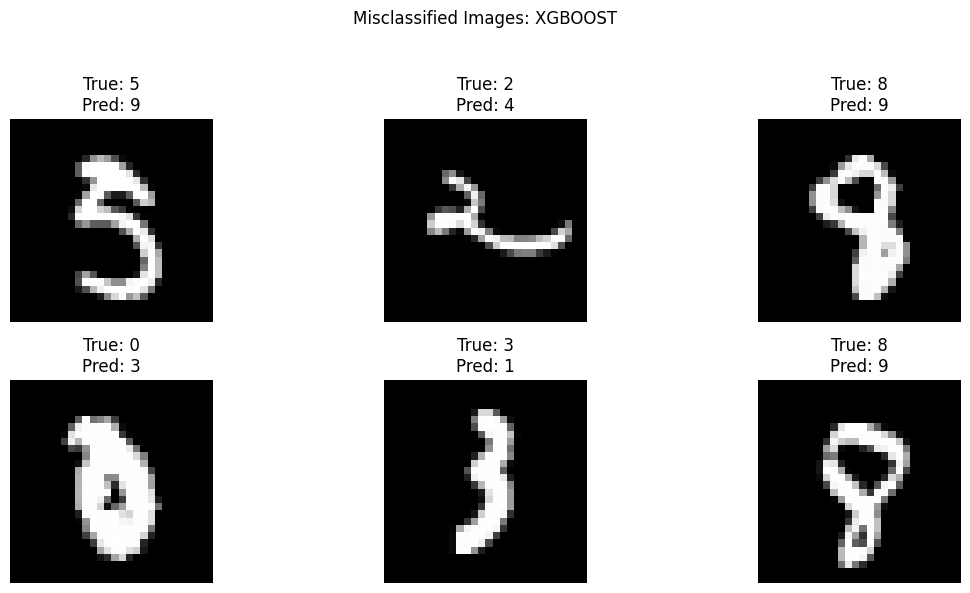

In [92]:

def plot_misclassified_images(X_test, y_test, y_predict, model_name, num_images=6):
    misclassified_indices = [i for i, (true, pred) in enumerate(zip(y_test, y_predict)) if true != pred]
    if len(misclassified_indices) == 0:
        print(f"No misclassified images for {model_name}.")
        return
    sample_indices = random.sample(misclassified_indices, min(num_images, len(misclassified_indices)))
    plt.figure(figsize=(12, 6))
    for idx, mis_idx in enumerate(sample_indices):
        image = X_test.iloc[mis_idx].values.reshape(28, 28)
        plt.subplot(2, (num_images+1)//2, idx+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"True: {y_test.iloc[mis_idx]}\nPred: {y_predict[mis_idx]}")
        plt.axis('off')
    plt.suptitle(f"Misclassified Images: {model_name}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_misclassified_images(X_test, y_test, y_predict, "Logistic Regression")

plot_misclassified_images(X_test, y_test, SVC_Y_PRED, "SVM")

plot_misclassified_images(X_test, y_test, y_pred_rf, "Random Forest")

plot_misclassified_images(X_test, y_test, y_pred_tree, "Decision Tree")

plot_misclassified_images(X_test, y_testXG, y_pred_xgb, "XGBOOST")

# 5. Output & Visualization

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

In [94]:
model_accuracies = {'Logistic Regression': accuracy_score(y_test, y_predict),
    'SVM': accuracy_score(y_test, SVC_Y_PRED),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Decision Tree': accuracy_score(y_test, y_pred_tree),
    'XGBoost': accuracy_score(y_testXG, y_pred_xgb)}
acc_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])

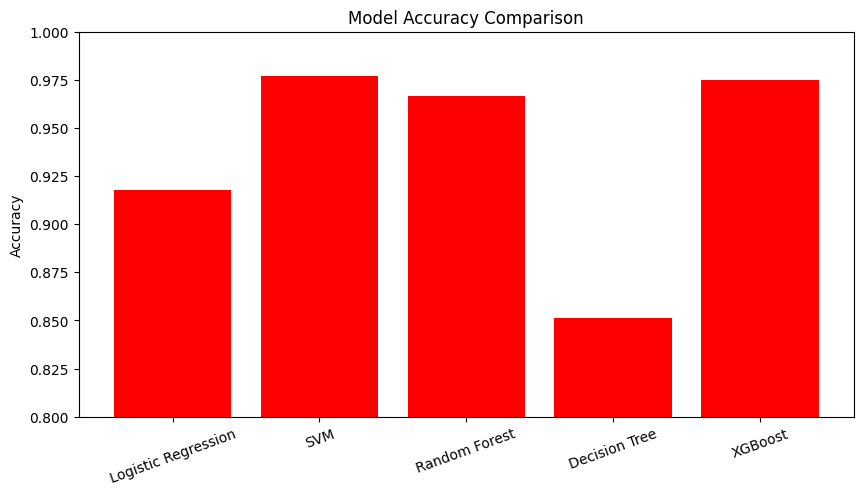

                 Model  Accuracy
0  Logistic Regression  0.917667
1                  SVM  0.976762
2        Random Forest  0.966524
3        Decision Tree  0.851190
4              XGBoost  0.974905


In [ ]:
plt.figure(figsize=(10,5))
plt.bar(acc_df['Model'], acc_df['Accuracy'], color='red')
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=20)
plt.show()

print(acc_df)